In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data_limpio/dataset_modelable_10s.csv")

df["Time"] = pd.to_datetime(df["Time"])

df.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,SP_PT442,PV442,TT413,TT415,LT426,SP_LT426,ACCION_PCT02,FT428,PIT410,PIT414
0,2021-11-05 08:00:00,58.142360,60.0,100.0,1229.492151,58.408563,3054.785938,69.0,59.5,0.154167,0.14,0.0,80.976565,81.82292,50.439814,50.0,18.861438,6.266928,0.326085,0.579514
1,2021-11-05 08:00:10,57.962962,60.0,100.0,1229.049451,58.272569,3052.526001,69.0,59.5,0.154282,0.14,0.0,80.954863,81.81424,50.422452,50.0,19.102801,6.293403,0.326181,0.579456
2,2021-11-05 08:00:20,57.323494,60.0,100.0,1229.088501,58.234953,3038.494727,69.0,59.5,0.154225,0.14,0.0,80.946182,81.81424,50.434027,50.0,19.315793,6.325521,0.326403,0.579051
3,2021-11-05 08:00:30,57.335069,60.0,100.0,1228.762976,58.463541,3031.794189,69.0,59.5,0.154282,0.14,0.0,80.946182,81.81424,50.422452,50.0,19.470506,6.357205,0.326340,0.578588
4,2021-11-05 08:00:40,57.835647,60.0,100.0,1229.453088,58.159721,3036.406226,69.0,59.5,0.154485,0.14,0.0,80.946182,81.81424,50.428239,50.0,19.712129,6.391927,0.326403,0.578125


In [5]:
df = df.sort_values("Time").reset_index(drop=True)

inicio = df["Time"].min()

df["segundos_desde_inicio"] = (df["Time"] - inicio).dt.total_seconds()
df["muestra_10s"] = df["segundos_desde_inicio"] / 10

df["dia_operacion"] = (df["segundos_desde_inicio"] // (24 * 3600)) + 1
df["dia_operacion"] = df["dia_operacion"].astype(int)

df["segundos_dia"] = df["segundos_desde_inicio"] - ((df["dia_operacion"] - 1) * 24 * 3600)

df[["Time", "dia_operacion", "segundos_desde_inicio", "segundos_dia", "muestra_10s"]].head()

,Time,dia_operacion,segundos_desde_inicio,segundos_dia,muestra_10s
0,2021-11-05 08:00:00,1,0.0,0.0,0.0
1,2021-11-05 08:00:10,1,10.0,10.0,1.0
2,2021-11-05 08:00:20,1,20.0,20.0,2.0
3,2021-11-05 08:00:30,1,30.0,30.0,3.0
4,2021-11-05 08:00:40,1,40.0,40.0,4.0


In [6]:
df["periodo"] = "sin_asignar"

df.loc[df["dia_operacion"] == 1, "periodo"] = "train"
df.loc[df["dia_operacion"] == 2, "periodo"] = "valid"
df.loc[df["dia_operacion"] == 3, "periodo"] = "test"

df["periodo"].value_counts()

periodo
train    8640
valid    8640
test     5790
Name: count, dtype: int64

In [7]:
target = "LT411"

features_modelo_A = [
    "DT412",
    "INT_P101",
    "FQC400_1",
    "FV400_1",
    "PT442",
    "PV442",
    "TT413",
    "TT415",
    "PIT410",
    "PIT414"
]

In [8]:
X = df[features_modelo_A]
y = df[target]
periodo = df["periodo"]

In [9]:
# Entrenamiento: Día 1
X_train = X[df["dia_operacion"] == 1]
y_train = y[df["dia_operacion"] == 1]

# Validación: Día 2
X_valid = X[df["dia_operacion"] == 2]
y_valid = y[df["dia_operacion"] == 2]

# Test: Día 3
X_test = X[df["dia_operacion"] == 3]
y_test = y[df["dia_operacion"] == 3]

In [10]:
lags = [1, 3, 6, 30, 60, 90]

In [11]:
df_modelo = df.copy()

features_base = [
    "DT412",
    "INT_P101",
    "FQC400_1",
    "FV400_1",
    "PT442",
    "PV442",
    "TT413",
    "TT415",
    "PIT410",
    "PIT414"
]

lags = [1, 3, 6, 30, 60, 90]

for variable in features_base:
    for lag in lags:
        df_modelo[f"{variable}_lag_{lag}"] = df_modelo[variable].shift(lag)

df_modelo.head()

,Time,LT411,SP_LT411,LV411,DT412,INT_P101,FQC400_1,SP_VAPOR,FV400_1,PT442,...,PIT410_lag_6,PIT410_lag_30,PIT410_lag_60,PIT410_lag_90,PIT414_lag_1,PIT414_lag_3,PIT414_lag_6,PIT414_lag_30,PIT414_lag_60,PIT414_lag_90
0,2021-11-05 08:00:00,58.142360,60.0,100.0,1229.492151,58.408563,3054.785938,69.0,59.5,0.154167,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-11-05 08:00:10,57.962962,60.0,100.0,1229.049451,58.272569,3052.526001,69.0,59.5,0.154282,...,NaN,NaN,NaN,NaN,0.579514,NaN,NaN,NaN,NaN,NaN
2,2021-11-05 08:00:20,57.323494,60.0,100.0,1229.088501,58.234953,3038.494727,69.0,59.5,0.154225,...,NaN,NaN,NaN,NaN,0.579456,NaN,NaN,NaN,NaN,NaN
3,2021-11-05 08:00:30,57.335069,60.0,100.0,1228.762976,58.463541,3031.794189,69.0,59.5,0.154282,...,NaN,NaN,NaN,NaN,0.579051,0.579514,NaN,NaN,NaN,NaN
4,2021-11-05 08:00:40,57.835647,60.0,100.0,1229.453088,58.159721,3036.406226,69.0,59.5,0.154485,...,NaN,NaN,NaN,NaN,0.578588,0.579456,NaN,NaN,NaN,NaN


In [12]:
df_modelo = df_modelo.dropna()

df_modelo.shape

(22980, 85)

In [13]:
target = "LT411"

features_lags = []

for variable in features_base:
    features_lags.append(variable)
    
    for lag in lags:
        features_lags.append(f"{variable}_lag_{lag}")

X = df_modelo[features_lags]
y = df_modelo[target]

In [14]:
X_train = X[df_modelo["periodo"] == "train"]
y_train = y[df_modelo["periodo"] == "train"]

X_valid = X[df_modelo["periodo"] == "valid"]
y_valid = y[df_modelo["periodo"] == "valid"]

X_test = X[df_modelo["periodo"] == "test"]
y_test = y[df_modelo["periodo"] == "test"]

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

X_train: (8550, 70)
X_valid: (8640, 70)
X_test: (5790, 70)


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
pred_train = modelo_rf.predict(X_train)
pred_valid = modelo_rf.predict(X_valid)
pred_test = modelo_rf.predict(X_test)

In [18]:
def evaluar_modelo(y_real, y_pred, nombre):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = mean_squared_error(y_real, y_pred) ** 0.5
    r2 = r2_score(y_real, y_pred)
    
    return {
        "dataset": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [19]:
resultados = pd.DataFrame([
    evaluar_modelo(y_train, pred_train, "train_dia1"),
    evaluar_modelo(y_valid, pred_valid, "valid_dia2"),
    evaluar_modelo(y_test, pred_test, "test_dia3")
])

resultados

,dataset,MAE,RMSE,R2
0,train_dia1,0.450575,0.600487,0.972469
1,valid_dia2,4.500042,6.158271,0.003269
2,test_dia3,16.507860,28.357827,-0.260181


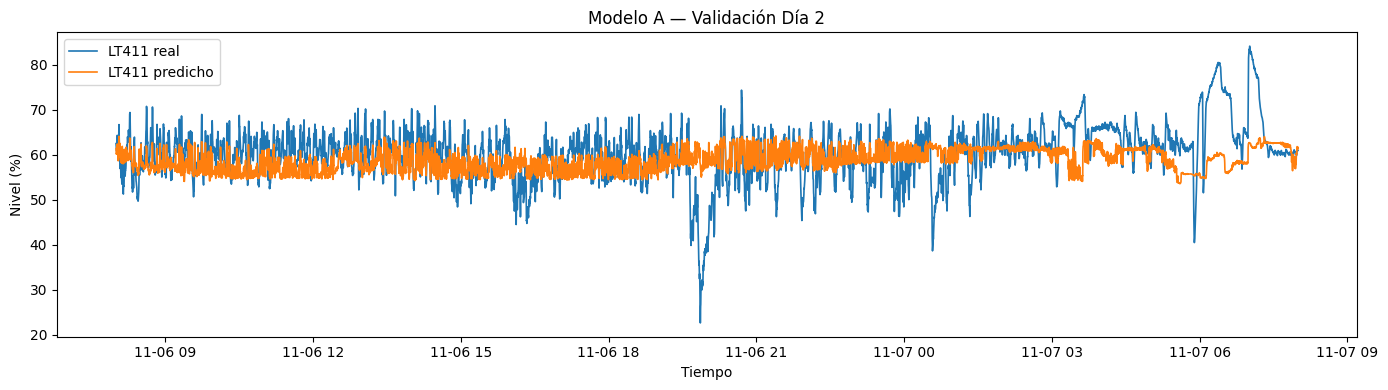

In [20]:
df_valid_resultado = df_modelo[df_modelo["periodo"] == "valid"].copy()

df_valid_resultado["LT411_pred"] = pred_valid

plt.figure(figsize=(14, 4))

plt.plot(
    df_valid_resultado["Time"],
    df_valid_resultado["LT411"],
    label="LT411 real",
    linewidth=1.2
)

plt.plot(
    df_valid_resultado["Time"],
    df_valid_resultado["LT411_pred"],
    label="LT411 predicho",
    linewidth=1.2
)

plt.title("Modelo A — Validación Día 2")
plt.xlabel("Tiempo")
plt.ylabel("Nivel (%)")
plt.legend()
plt.tight_layout()
plt.show()

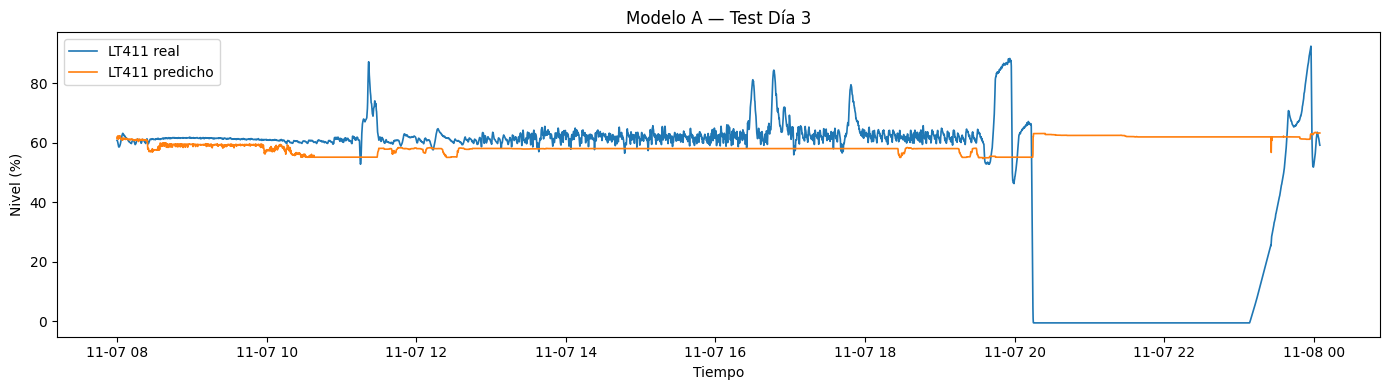

In [21]:
df_test_resultado = df_modelo[df_modelo["periodo"] == "test"].copy()

df_test_resultado["LT411_pred"] = pred_test

plt.figure(figsize=(14, 4))

plt.plot(
    df_test_resultado["Time"],
    df_test_resultado["LT411"],
    label="LT411 real",
    linewidth=1.2
)

plt.plot(
    df_test_resultado["Time"],
    df_test_resultado["LT411_pred"],
    label="LT411 predicho",
    linewidth=1.2
)

plt.title("Modelo A — Test Día 3")
plt.xlabel("Tiempo")
plt.ylabel("Nivel (%)")
plt.legend()
plt.tight_layout()
plt.show()

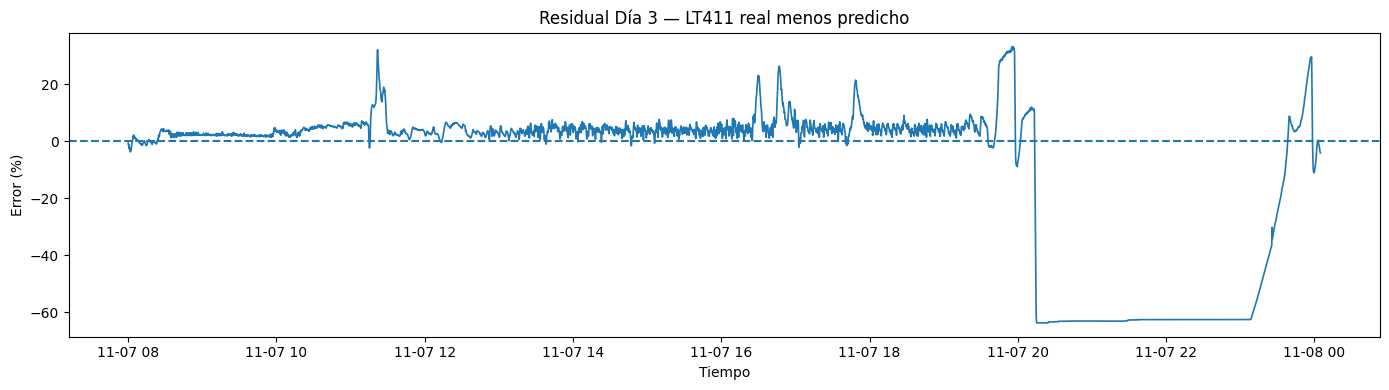

In [22]:
df_test_resultado["error"] = df_test_resultado["LT411"] - df_test_resultado["LT411_pred"]
df_test_resultado["error_abs"] = abs(df_test_resultado["error"])

plt.figure(figsize=(14, 4))

plt.plot(
    df_test_resultado["Time"],
    df_test_resultado["error"],
    linewidth=1.2
)

plt.axhline(0, linestyle="--")

plt.title("Residual Día 3 — LT411 real menos predicho")
plt.xlabel("Tiempo")
plt.ylabel("Error (%)")
plt.tight_layout()
plt.show()

In [23]:
importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values("importancia", ascending=False)

importancias.head(20)

,feature,importancia
8,INT_P101_lag_1,0.193701
63,PIT414,0.060720
7,INT_P101,0.050141
30,PT442_lag_3,0.033564
0,DT412,0.029174
29,PT442_lag_1,0.027118
33,PT442_lag_60,0.026312
28,PT442,0.026001
58,PIT410_lag_3,0.024913
31,PT442_lag_6,0.023322


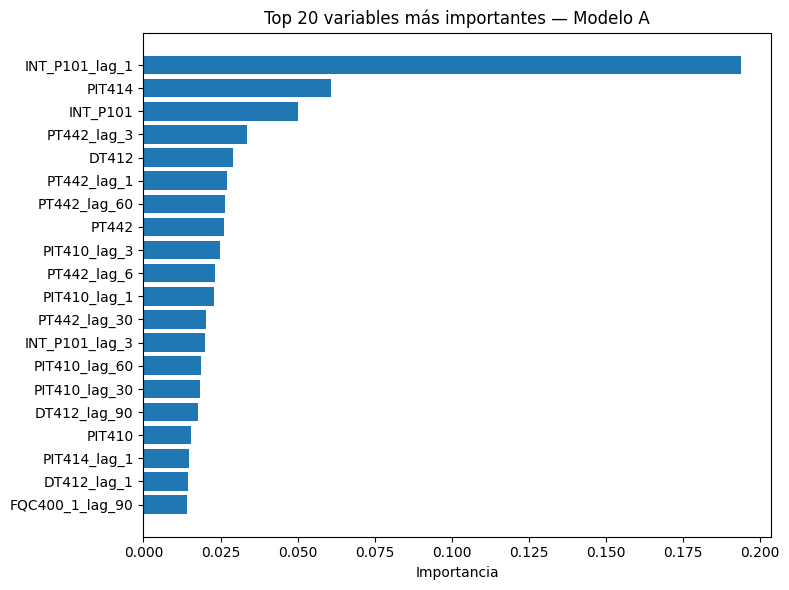

In [24]:
top_importancias = importancias.head(20).sort_values("importancia")

plt.figure(figsize=(8, 6))
plt.barh(top_importancias["feature"], top_importancias["importancia"])
plt.title("Top 20 variables más importantes — Modelo A")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelos = {
    "Dummy_media": DummyRegressor(strategy="mean"),
    
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    )
}

In [26]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = mean_squared_error(y_real, y_pred) ** 0.5
    r2 = r2_score(y_real, y_pred)
    
    return mae, rmse, r2

In [27]:
resultados_modelos = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo
    
    pred_train = modelo.predict(X_train)
    pred_valid = modelo.predict(X_valid)
    pred_test = modelo.predict(X_test)
    
    mae_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
    mae_valid, rmse_valid, r2_valid = calcular_metricas(y_valid, pred_valid)
    mae_test, rmse_test, r2_test = calcular_metricas(y_test, pred_test)
    
    resultados_modelos.append({
        "modelo": nombre,
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_valid": mae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
        "R2_test": r2_test
    })

resultados_modelos = pd.DataFrame(resultados_modelos)

resultados_modelos.sort_values("MAE_valid")

,modelo,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid,MAE_test,RMSE_test,R2_test
4,ExtraTrees,5.683223e-10,4.682643e-09,1.000000,4.380530,6.063648,0.033664,16.183541,28.327833,-0.257517
0,Dummy_media,2.838138e+00,3.619011e+00,0.000000,4.436615,6.190291,-0.007123,14.618432,27.038652,-0.145664
3,RandomForest,4.505750e-01,6.004868e-01,0.972469,4.500042,6.158271,0.003269,16.507860,28.357827,-0.260181
6,HistGradientBoosting,7.233669e-01,9.094032e-01,0.936856,4.596646,6.340415,-0.056563,16.960910,28.488946,-0.271861
5,GradientBoosting,1.566928e+00,1.950361e+00,0.709564,4.769995,6.580998,-0.138266,16.638872,28.117720,-0.238931
2,Ridge,1.447366e+00,1.830205e+00,0.744248,23.487511,60.181761,-94.189719,164.963863,243.217775,-91.699562
1,LinearRegression,1.444545e+00,1.827827e+00,0.744912,23.831226,60.978303,-96.726179,162.798448,241.656973,-90.513618
